In [ ]:
""" Imports and Setup. """
import sys
import pandas as pd
import numpy as np
sys.path.append("/Users/emilieyu/endotehelial-masboss")
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpatches 

from src.config import load_sim_config, load_sweep_config, load_spatial_config
from src.paths import BM_RESULTS_DIR

sim_cfg = load_sim_config()
sweep_cfg = load_sweep_config()
spatial_cfg = load_spatial_config()

from abm_v1.flow_field import FlowField
from abm_v1.endothelial_cell import EndothelialCell
from abm_v1.membrane_node import MembraneNode
from abm_v1.spring import Spring
from abm_v1_v2.rho_lookup_table import RhoLookupTable

class MockLUT:
    """Stub LUT returning fixed balanced Rho — used for mechanics tests."""
    rhoa_rest = 0.3
    rhoc_rest = 0.3
    def query(self, dsp, tjp1, jcad):
        return 0.5, 0.5

def check(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    print(f"  [{status}] {name}" + (f" — {detail}" if detail else ""))
    return condition

def plot_cell(cell):

    pos = cell.positions
    x, y = pos[:, 0], pos[:, 1]
    c = cell.centroid

    plt.figure()
    plt.scatter(x, y)
    for node, (xi, yi) in zip(cell.nodes, pos):
        plt.text(xi, yi, str(node.id), fontsize=9, ha='right', va='bottom')

    plt.scatter(c[0]+0.2, c[1]+0.2, marker='x', s=100)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    plt.close()

In [3]:
LUT = RhoLookupTable(spatial_cfg, BM_RESULTS_DIR)
LUT

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437


## 1: Test MembraneNode In Isolation

In [3]:
""" Force Accumulation """
node = MembraneNode(0, np.array([0.0, 0.0]))
node.apply_force(np.array([1.0, 0.0]))
node.apply_force(np.array([0.0, 2.0]))
check("force accumulates across calls", np.allclose(node.force, [1.0, 2.0]),
      f"force={node.force}")

"""
Integration — dx = (F/gamma)*dt 
= ([1,2]/1)*0.1 = [0.1, 0.2]
"""
node.update(dt=0.1, gamma=1.0)
check("position updates correctly", np.allclose(node.pos, [0.1, 0.2], atol=1e-6),
      f"pos={node.pos}")
check("force resets after update", np.allclose(node.force, [0.0, 0.0]),
      f"force={node.force}")

""" Gamma scaling — higher gamma = smaller displacement """
node2 = MembraneNode(1, np.array([0.0, 0.0]))
node2.apply_force(np.array([1.0, 0.0]))
node2.update(dt=0.1, gamma=5.0)
check("gamma=5 gives 5x smaller displacement",
      np.allclose(node2.pos, [0.02, 0.0], atol=1e-6),
      f"pos={node2.pos}")

""" Displacement cap """
node3 = MembraneNode(2, np.array([0.0, 0.0]))
node3.apply_force(np.array([1e6, 0.0]))
node3.update(dt=0.1, gamma=1.0, max_displacement=1.0)
check("displacement cap prevents teleporting",
      np.linalg.norm(node3.pos) <= 1.0 + 1e-6,
      f"displacement={np.linalg.norm(node3.pos):.4f}")

""" NaN rejection """
node4 = MembraneNode(3, np.array([0.0, 0.0]))
try:
    node4.apply_force(np.array([np.nan, 0.0]))
    check("NaN force rejected", False, "no error raised")
except ValueError:
    check("NaN force rejected", True)

  [PASS] force accumulates across calls — force=[1. 2.]
>>> DEBUG: Node(0): Calculated displacement: [0.1 0.2]
  [PASS] position updates correctly — pos=[0.1 0.2]
  [PASS] force resets after update — force=[0. 0.]
>>> DEBUG: Node(1): Calculated displacement: [0.02 0.  ]
  [PASS] gamma=5 gives 5x smaller displacement — pos=[0.02 0.  ]
>>> DEBUG: Node(2): Calculated displacement: [100000.      0.]
  [PASS] displacement cap prevents teleporting — displacement=1.0000
  [PASS] NaN force rejected


## 2 Test Spring Geometry and Tension in Isolation

In [4]:

n1  = MembraneNode(0, np.array([0.0, 0.0]))
n2  = MembraneNode(1, np.array([5.0, 0.0]))
lut = MockLUT()
s   = Spring(0, n1, n2, rest_length=5.0, lut=lut, cfg=spatial_cfg, k_cortex=1.0)
fd  = np.array([1.0, 0.0])

# At rest
s.update_geometry(fd)
check("zero tension_total at rest", abs(s.tension_total) < 1e-6,
      f"tension={s.tension_total:.6f}")

# Stretched — tension positive, forces pull nodes together
n2.pos = np.array([6.0, 0.0])
s.update_geometry(fd)
check("tension positive when stretched", s.tension_total > 0,
      f"tension={s.tension_total:.4f}")
s.apply_forces()
check("stretched: n1 pulled toward n2 (+x)", n1.force[0] > 0,
      f"n1.force={n1.force.round(4)}")
check("stretched: n2 pulled toward n1 (-x)", n2.force[0] < 0,
      f"n2.force={n2.force.round(4)}")
n1.force[:] = 0; n2.force[:] = 0

# Compressed — tension negative, forces push nodes apart
n2.pos = np.array([4.0, 0.0])
s.update_geometry(fd)
check("tension negative when compressed", s.tension_total < 0,
      f"tension={s.tension_total:.4f}")
check("compressive stiffness < tensile (kc_ratio=0.1)",
      abs(s.tension_total) < 0.15,
      f"|tension|={abs(s.tension_total):.4f}  expected≈0.1")

# Alignment
n2.pos = np.array([6.0, 0.0])
s.update_geometry(fd)
check("alignment=1 when parallel to flow", abs(s.alignment - 1.0) < 1e-6,
      f"alignment={s.alignment:.4f}")

n2.pos = np.array([0.0, 6.0])
s.update_geometry(fd)
check("alignment=0 when perpendicular to flow", abs(s.alignment) < 1e-6,
      f"alignment={s.alignment:.4f}")

# Stress fibre tension
n2.pos = np.array([6.0, 0.0])   # stretched + aligned
s.update_geometry(fd)
check("t_sf > 0 on stretched aligned spring", s.tension_sf > 0,
      f"t_sf={s.tension_sf:.4f}")

n2.pos = np.array([0.0, 6.0])   # stretched + perpendicular
s.update_geometry(fd)
check("t_sf = 0 on perpendicular spring", abs(s.tension_sf) < 1e-6,
      f"t_sf={s.tension_sf:.4f}")

  [PASS] zero tension_total at rest — tension=0.000000
  [PASS] tension positive when stretched — tension=1.4000
  [PASS] stretched: n1 pulled toward n2 (+x) — n1.force=[1.4 0. ]
  [PASS] stretched: n2 pulled toward n1 (-x) — n2.force=[-1.4  0. ]
  [PASS] tension negative when compressed — tension=-0.1000
  [PASS] compressive stiffness < tensile (kc_ratio=0.1) — |tension|=0.1000  expected≈0.1
  [PASS] alignment=1 when parallel to flow — alignment=1.0000
  [PASS] alignment=0 when perpendicular to flow — alignment=0.0000
  [PASS] t_sf > 0 on stretched aligned spring — t_sf=0.4000
  [PASS] t_sf = 0 on perpendicular spring — t_sf=0.0000


np.True_

## 3 Spring Remodelling Over Time In Isolation

  [PASS] k_active rises above baseline after 500 steps — k_active=1.6298
  [PASS] L_sf drops below L_cortex after 500 steps — lsf_ratio=0.9213


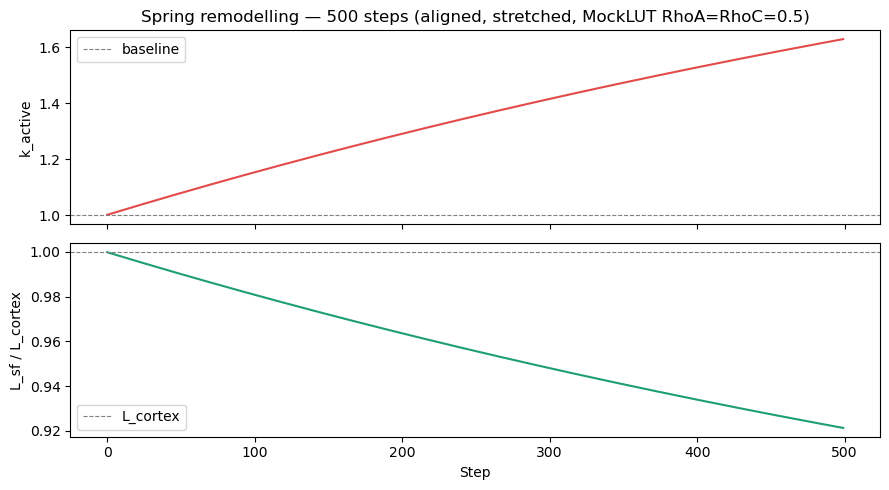

In [5]:
n1 = MembraneNode(0, np.array([0.0, 0.0]))
n2 = MembraneNode(1, np.array([6.0, 0.0]))
s  = Spring(0, n1, n2, rest_length=5.0, lut=MockLUT(),
            cfg=spatial_cfg, k_cortex=1.0)
fd = np.array([1.0, 0.0])

k_history   = []
lsf_history = []

for i in range(500):
    s.update_geometry(fd)
    s.update_signalling()
    s.update_remodelling(dt=0.1)
    k_history.append(s.k_active)
    lsf_history.append(s.L_sf / s.L_cortex)

check("k_active rises above baseline after 500 steps",
      s.k_active > 1.0,
      f"k_active={s.k_active:.4f}")
check("L_sf drops below L_cortex after 500 steps",
      s.L_sf < s.L_cortex,
      f"lsf_ratio={s.L_sf/s.L_cortex:.4f}")

steps = list(range(500))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(steps, k_history, color='#E24B4A', linewidth=1.5)
ax1.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='baseline')
ax1.set_ylabel("k_active")
ax1.set_title("Spring remodelling — 500 steps (aligned, stretched, MockLUT RhoA=RhoC=0.5)")
ax1.legend()

ax2.plot(steps, lsf_history, color='#1D9E75', linewidth=1.5)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='L_cortex')
ax2.set_ylabel("L_sf / L_cortex")
ax2.set_xlabel("Step")
ax2.legend()
plt.tight_layout()
plt.show()

## 4 Flow Field in Isolation

  [PASS] upstream node: weight=1.0 — force=[1. 0.]
  [PASS] downstream node: weight=0.0 — force=[0. 0.]
  [PASS] lateral node: weight=0.5 — force=[0.5 0. ]


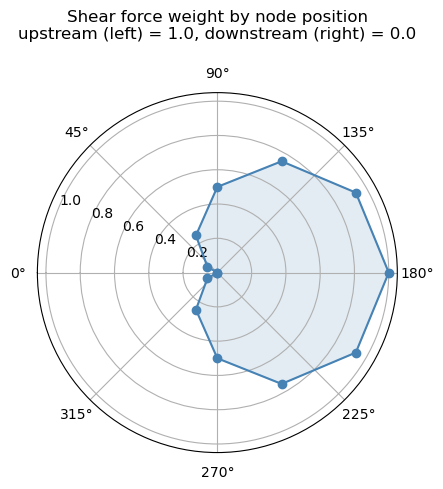

In [6]:

flow     = FlowField(magnitude=1.0)
centroid = np.array([0.0, 0.0])

f_up   = flow.get_force_on_node(np.array([-10.0,  0.0]), centroid)
f_down = flow.get_force_on_node(np.array([ 10.0,  0.0]), centroid)
f_lat  = flow.get_force_on_node(np.array([  0.0, 10.0]), centroid)

check("upstream node: weight=1.0",  np.allclose(f_up,   [1.0, 0.0], atol=1e-6), f"force={f_up}")
check("downstream node: weight=0.0",np.allclose(f_down, [0.0, 0.0], atol=1e-6), f"force={f_down}")
check("lateral node: weight=0.5",   np.allclose(f_lat,  [0.5, 0.0], atol=1e-6), f"force={f_lat}")

# Polar plot of weight around a 12-node ring
angles  = np.linspace(0, 2 * np.pi, 12, endpoint=False)
weights = []
for a in angles:
    pos = np.array([10.0 * np.cos(a), 10.0 * np.sin(a)])
    weights.append(np.linalg.norm(flow.get_force_on_node(pos, centroid)))

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(5, 5))
ax.plot(np.append(angles, angles[0]),
        np.append(weights, weights[0]),
        'o-', color='steelblue', linewidth=1.5)
ax.fill(np.append(angles, angles[0]),
        np.append(weights, weights[0]),
        alpha=0.15, color='steelblue')
ax.set_theta_zero_location('W')  # upstream on left, matching flow direction
ax.set_theta_direction(-1)
ax.set_title("Shear force weight by node position\nupstream (left) = 1.0, downstream (right) = 0.0",
             pad=20)
plt.tight_layout()
plt.show()

## 5 Endothelial Cell Area Conservation

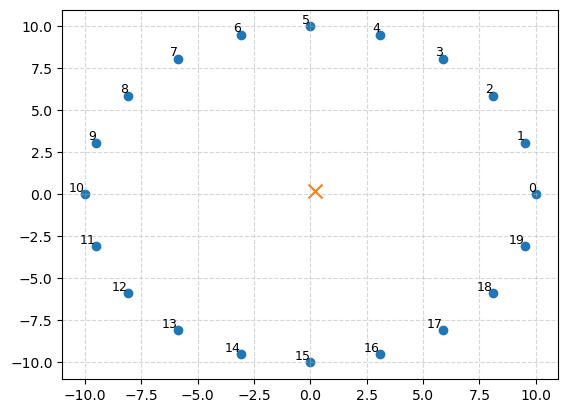

  [PASS] initial area matches 20-gon formula — area=309.017  expected≈309.017
  [PASS] initial AR ≈ 1.0 — ar=1.0
  [PASS] area stays within 15% over 500 steps — max area error=0.011
  [PASS] AR increases under flow — AR: 1.000 → 3.233
  [PASS] AR plateaus (equilibrium reached) — peak=3.233 final=3.233


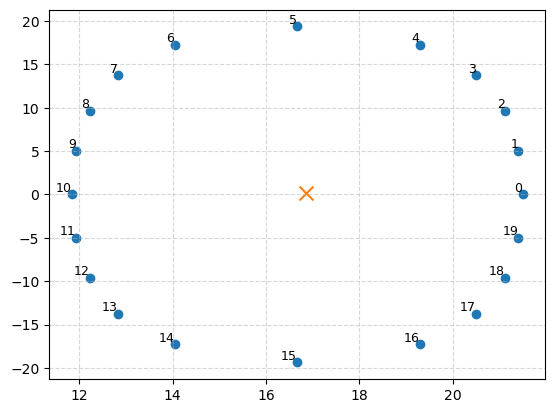

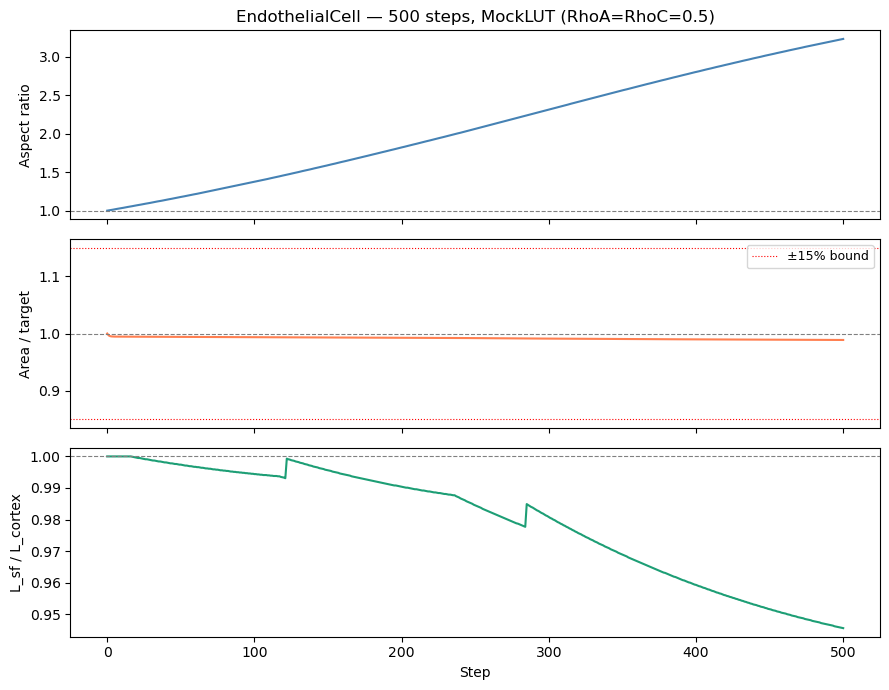

In [4]:

flow = FlowField(magnitude=2.0)
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=MockLUT(), cfg=spatial_cfg,
                       n_nodes=20, radius=10.0)
plot_cell(cell)

# Geometric expectation: area of regular 12-gon radius 10
expected_area = 0.5 * 20 * 10**2 * np.sin(2 * np.pi / 20)
check("initial area matches 20-gon formula",
      abs(cell.target_area - expected_area) < 1.0,
      f"area={cell.target_area:.3f}  expected≈{expected_area:.3f}")

s0 = cell.get_state()
check("initial AR ≈ 1.0",
      abs(s0['metrics']['ar'] - 1.0) < 0.05,
      f"ar={s0['metrics']['ar']}")

# Run 200 steps
area_0   = cell.target_area
areas, ars, lsf_ratios = [cell.current_area], [s0['metrics']['ar']], [1.0]

for _ in range(500):
    cell.step(flow, dt=0.1)
    s = cell.get_state()
    areas.append(cell.current_area)
    ars.append(s['metrics']['ar'])
    lsf_ratios.append(s['remodelling']['mean_lsf_ratio'])

area_errs    = [a / area_0 for a in areas]
max_area_err = max(abs(e - 1.0) for e in area_errs)

check("area stays within 15% over 500 steps",
      max_area_err < 0.15,
      f"max area error={max_area_err:.3f}")
check("AR increases under flow",
      ars[-1] > 1.1,
      f"AR: {ars[0]:.3f} → {ars[-1]:.3f}")

check("AR plateaus (equilibrium reached)",
      abs(ars[-1] - max(ars)) < 0.15,  # within 0.15 of peak
      f"peak={max(ars):.3f} final={ars[-1]:.3f}")

plot_cell(cell)

steps = list(range(len(ars)))
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

axes[0].plot(steps, ars, color='steelblue', linewidth=1.5)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_ylabel("Aspect ratio")
axes[0].set_title("EndothelialCell — 500 steps, MockLUT (RhoA=RhoC=0.5)")

axes[1].plot(steps, area_errs, color='coral', linewidth=1.5)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axhline(1.15, color='red', linestyle=':', linewidth=0.8, label='±15% bound')
axes[1].axhline(0.85, color='red', linestyle=':', linewidth=0.8)
axes[1].set_ylabel("Area / target")
axes[1].legend(fontsize=9)

axes[2].plot(steps, lsf_ratios, color='#1D9E75', linewidth=1.5)
axes[2].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_ylabel("L_sf / L_cortex")
axes[2].set_xlabel("Step")

plt.tight_layout()
plt.show()
plt.close()

### Diagnostics: Area Oscillation

In [3]:
# Diagnostic — print per-step area and AR for first 10 steps
cell_diag = EndothelialCell(0, np.array([0.0, 0.0]),
                            lut=MockLUT(), cfg=spatial_cfg,
                            n_nodes=12, radius=10.0)
flow_diag = FlowField(magnitude=0.5)

print(f"{'step':>4}  {'area_err':>8}  {'AR':>6}  {'pressure':>10}")
area_0 = cell_diag.target_area
for t in range(10):
    # Compute pressure before stepping
    current = cell_diag._compute_area()
    pressure = spatial_cfg['mechanics']['k_area'] * (area_0 - current)
    s = cell_diag.get_state()
    print(f"{t:4d}  {current/area_0:8.4f}  {s['metrics']['ar']:6.4f}  {pressure:10.4f}")
    cell_diag.step(flow_diag, dt=0.1)

DEBUG: Initialised Cell 0: 
EndothelialCell(id=0 | n=12 | centroid=[-0.  0.] | ar=1.00 | area_err=1.000 | rho_bal=+0.000 | lsf=1.000 | t_sf=0.0000)
step  area_err      AR    pressure
   0    1.0000  1.0000      0.0000
   1    0.9988  1.0010      0.1875
   2    0.9994  1.0030      0.0937
   3    0.9991  1.0040      0.1417
   4    0.9992  1.0050      0.1182
   5    0.9991  1.0060      0.1308
   6    0.9992  1.0070      0.1251
   7    0.9991  1.0090      0.1287
   8    0.9991  1.0100      0.1275
   9    0.9991  1.0110      0.1289


### Diagnostics: Plateu of AR

DEBUG: Initialised Cell 0: 
EndothelialCell(id=0 | n=12 | centroid=[-0.  0.] | ar=1.00 | area_err=1.000 | rho_bal=+0.000 | lsf=1.000 | t_sf=0.0000)


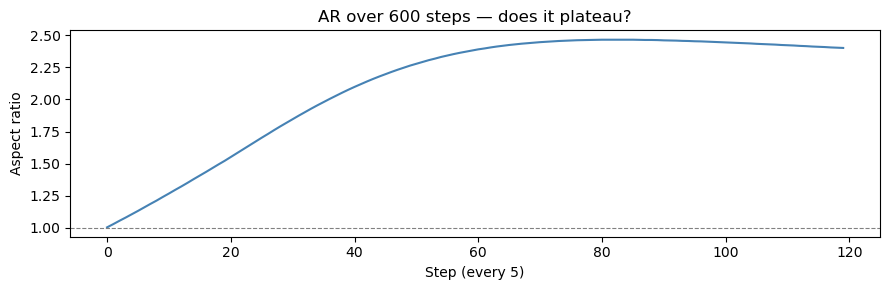

AR at step 600: 2.400
Plateaued


In [5]:
# Does AR plateau if you run longer?
cell_long = EndothelialCell(0, np.array([0.0, 0.0]),
                            lut=MockLUT(), cfg=spatial_cfg,
                            n_nodes=12, radius=10.0)
flow_long = FlowField(magnitude=2.0)

ars_long = []
for t in range(600):
    cell_long.step(flow_long, dt=0.1)
    if t % 5 == 0:
        ars_long.append(cell_long.get_state()['metrics']['ar'])

plt.figure(figsize=(9, 3))
plt.plot(range(len(ars_long)), ars_long, color='steelblue', linewidth=1.5)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel("Aspect ratio")
plt.xlabel("Step (every 5)")
plt.title("AR over 600 steps — does it plateau?")
plt.tight_layout()
plt.show()

final_ar = ars_long[-1]
print(f"AR at step 600: {final_ar:.3f}")
print("Plateaued" if abs(ars_long[-1] - ars_long[-10]) < 0.05 else "Still rising — no equilibrium")

AR rises to ~2.45 and plateaus around step 60 (300 actual steps), then shows a very slight decline toward ~2.38. The plateau confirms the cell is finding a mechanical equilibrium between shear force and spring restoring forces. The slight decline after the peak is the stress fibre remodelling continuing to shorten L_sf — as fibres shorten further they pull lateral nodes inward more strongly, which slightly reduces AR as the geometry becomes more uniformly contracted. This is biologically plausible.